# Score de risque CG10 — Prédiction d'un éclair nuage-sol dans les 30 prochaines minutes

## Contexte

Dans le cadre de la sécurité aéroportuaire, la foudre de type **nuage-sol (CG)** représente un danger direct pour les opérations au sol. L'objectif de ce notebook est de construire un **score de risque** permettant d'anticiper la survenue d'un tel éclair dans les **30 prochaines minutes** à proximité d'un aéroport (≤ 3 km).

Ce score, fondé sur l'historique récent de l'activité orageuse, doit être :
- **Discriminant** : distinguer les situations à risque des situations calmes
- **Stable** : performant sur des périodes non vues (OOT 2022)
- **Lisible** : interprétable par les opérationnels via des Classes Homogènes de Risque (CHR)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

Les données météo pré-traitées sont chargées depuis le fichier pickle produit par la phase de feature engineering. Ce fichier contient le DataFrame enrichi (`df`), la liste des variables candidates (`VAR`), les dummies et les identifiants.

In [18]:
import joblib
path = '..\\data\\meteo_data_clipped.pkl'
meteo_data = joblib.load(path)

In [19]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [20]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [21]:

# 1️⃣ identifier les éclairs cloud-ground dans 3 km
df["cg_3km"] = (
    (~df["icloud"]) &
    (df["dist"] <= 3)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg3_date"] = df["date"].where(df["cg_3km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg3_date"] = (
    df.groupby("airport")["cg3_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg3"] = (
    df["next_cg3_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg3"]  = df["time_to_next_cg3"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg3"].notna()]



## 2. Exploration de la variable cible `time_to_next_cg20`

Avant de définir la cible binaire, on analyse la distribution du **temps jusqu'au prochain CG ≤ 20 km**. La distribution est très asymétrique (médiane ~47 s, mais 90e percentile à 35 min), ce qui justifie le choix d'un seuil court de **10 minutes** pour capturer les situations à risque immédiat.

In [22]:
df['time_to_next_cg3'].describe()

count    505754.000000
mean       2608.895342
std        1382.236235
min           0.000000
25%        1171.000000
50%        3600.000000
75%        3600.000000
max        3600.000000
Name: time_to_next_cg3, dtype: float64

## 3. Définition de la cible binaire

**Formulation du problème de scoring** : pour chaque éclair observé, on veut prédire si un éclair CG surviendra dans les **10 prochaines minutes** à moins de 20 km de l'aéroport.

$$\text{next\_10min\_cg20} = \mathbb{1}[\text{time\_to\_next\_cg20} > 10 \text{ min}]$$

- `True` = **risque faible** (pas de CG dans les 10 prochaines minutes)
- `False` = **risque actif** (CG imminent)

> Note : la variable est définie comme "absence de CG" pour aligner la convention avec un score croissant.

In [23]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_30min_cg3'] = df['time_to_next_cg3'] <= (30 * 60) # LE prochain arrive dans moins de 30 minutes
df['next_30min_cg3'].value_counts()

next_30min_cg3
False    351831
True     153923
Name: count, dtype: int64

## 2. Construction de la cible binaire

On discrétise `time_to_next_cg20` avec le seuil à **30 minutes (900 secondes)**.

Le déséquilibre (~90% / 10%) est caractéristique des problèmes d'alerte :
la majorité du temps, un CG arrive dans les 30 minutes car les éclairs se produisent en rafales.
La classe rare (pas de CG imminent) est précisément ce que le score doit détecter.

Prévalence (pas de CG dans 30 min) : 30.43%
next_30min_cg3
False    351831
True     153923
Name: count, dtype: int64


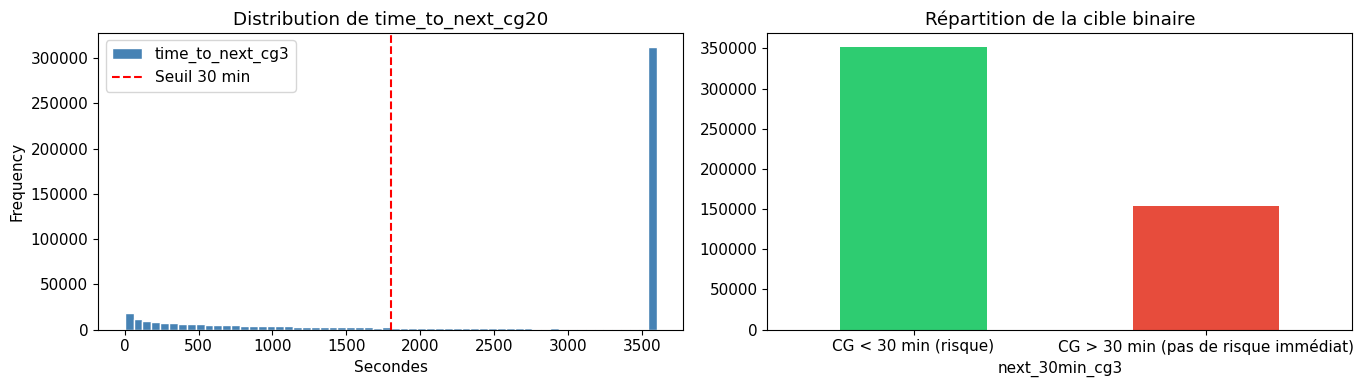

In [24]:
target_col = 'next_30min_cg3'
prevalence = df[target_col].mean()
print(f'Prévalence (pas de CG dans 30 min) : {prevalence:.2%}')
print(df[target_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['time_to_next_cg3'].plot.hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(1800, color='red', linestyle='--', label='Seuil 30 min')
axes[0].set_title('Distribution de time_to_next_cg20')
axes[0].set_xlabel('Secondes')
axes[0].legend()

df[target_col].value_counts().plot.bar(ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Répartition de la cible binaire')
axes[1].set_xticklabels(['CG < 30 min (risque)', 'CG > 30 min (pas de risque immédiat)'], rotation=0)
plt.tight_layout()
plt.show()

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




### Découpage temporel

- **Train** : 2015–2021, 70 % aléatoire stratifié — sert à l'entraînement et à la calibration des hyperparamètres
- **Test** : 2015–2021, 15 % restant — évaluation interne
- **OOT** : 2022 — données hors-temps, jamais vues lors du développement, servent de validation finale

In [25]:
from sklearn.model_selection import train_test_split

data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2021)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2022].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((343496, 113), (85874, 113), (76384, 113))

### Préparation des matrices X / y

On sépare les features (`VAR` + variables catégorielles encodées one-hot : `airport`, `season`) de la cible. L'encodage est aligné entre les trois jeux pour éviter tout décalage de colonnes.

In [26]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# IMPUTATION

In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit sur train uniquement
X_train[VAR] = imputer.fit_transform(X_train[VAR])

# Transform sur test et OOT avec les médianes du train
X_test[VAR] = imputer.transform(X_test[VAR])
X_oot[VAR]  = imputer.transform(X_oot[VAR])

print("Médianes utilisées :")
print(dict(zip(VAR+["airport",'season'], imputer.statistics_)))


Médianes utilisées :
{'min_dist_5min': np.float64(6.320863679763268), 'time_since_last_CG20_2': np.float64(3.828641396489095), 'log_count_30min': np.float64(5.717027701406222), 'amplitude_change': np.float64(0.043933239538239244), 'activity_decay': np.float64(1.0526315047487191), 'time_since_last_intra_cloud2': np.float64(1.6094379124341003), 'log_cg_count_10min': np.float64(3.1780538303479458), 'min_dist_1min': np.float64(10.590472070579136), 'cg_20km': np.float64(0.0), 'log_std_amplitude_10min': np.float64(2.338963233321176), 'is_cloud_ground': np.float64(0.0), 'log_cg_count_20min': np.float64(3.7612001156935624), 'burst_indicator': np.float64(1.0), 'hour': np.float64(13.0), 'storm_direction_change': np.float64(3.0240068237421953), 'time_since_last_cloud_ground2': np.float64(2.833213344056216), 'std_lat_10min': np.float64(0.07471941967869511), 'mean_dist_1min': np.float64(20.581788632795153), 'dist': np.float64(21.372488276815705), 'log_count_5min': np.float64(4.174387269895637), 'al

## 4. Sélection des variables candidates

Les variables sont pré-sélectionnées selon leur importance SHAP issue d'un premier modèle benchmark, en favorisant :
- l'**activité récente** (comptages log sur 5, 10, 20 min)
- la **distance minimale** (indicateur de proximité)
- la **dispersion angulaire** (étalement de l'orage)
- les **délais** depuis le dernier CG (inertie orageuse)

In [28]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 
           'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 
           'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 
           'log_count_1min', 'storm_spread', 'mean_dist_10min', 'log_ic_count_5min',
             'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 
             'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 
             'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min',
               'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

37

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_15min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



## 5. Modèle XGBoost

On entraîne un **XGBClassifier** (`binary:logistic`) avec les hyperparamètres optimisés par **Optuna** (50 trials, 3-fold CV stratifié sur le train). L'algorithme histogram (`tree_method=hist`) accélère l'entraînement sur ce volume de données (~350 k lignes).

In [30]:
# import optuna
# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective":        "binary:logistic",
#         "eval_metric":      "auc",
#         "tree_method":      "hist",
#         "random_state":     42,
#         "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
#         "max_depth":        trial.suggest_int("max_depth", 3, 8),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "gamma":            trial.suggest_float("gamma", 0, 15),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
#     }

#     model = XGBClassifier(**params,eval_set=[(X_test_enc, y_test)])
#     scores = cross_val_score(model, X_train_enc, y_train,
#                              cv=cv, scoring="roc_auc", n_jobs=-1)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=15, show_progress_bar=True)

# print(f"Meilleur AUC CV : {study.best_value:.4f}")
# print("Meilleurs paramètres :")
# study.best_params


### Hyperparamètres optimisés (Optuna — 3-fold CV)

Les paramètres ci-dessous ont été sélectionnés pour **maximiser le ROC AUC** en validation croisée stratifiée. La régularisation L1/L2 (`reg_alpha`, `reg_lambda`) et `min_child_weight` élevé limitent le surapprentissage.

In [31]:
params = {'n_estimators': 791,
 'max_depth': 7,
 'learning_rate': 0.18953249251578172,
 'subsample': 0.6894952927400104,
 'colsample_bytree': 0.9942012325748735,
 'gamma': 0.20551203959759956,
 'min_child_weight': 12,
 'reg_alpha': 0.5201158139444992,
 'reg_lambda': 1.2240878901657437}

model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    **params
)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_test_enc, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9942012325748735
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## 6. Évaluation des performances

Métriques calculées sur les trois jeux :

| Métrique | Description |
|---|---|
| **ROC AUC** | Discrimination globale (insensible au seuil) |
| **Gini** | 2 × AUC − 1, normalisé entre 0 et 1 |
| **PR AUC** | AUC de la courbe Précision-Rappel, adaptée aux classes déséquilibrées |
| **Ratio RP** | PR AUC / prévalence — un modèle aléatoire vaut 1.0 |

In [32]:
from sklearn.metrics import average_precision_score
y_pred = model_xgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_xgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_xgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_xgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.86      0.90      0.88     56956
           1       0.65      0.56      0.60     19428

    accuracy                           0.81     76384
   macro avg       0.75      0.73      0.74     76384
weighted avg       0.80      0.81      0.81     76384

ROC AUC TRAIN: 1.0000  |  Gini TRAIN: 1.0000
ROC AUC TEST:  0.9987 |  Gini Test: 0.9973
PR AUC TEST:   0.9982  |  Ratio RP: 3.1865
ROC AUC OOT:  0.8089 |  Gini OOT: 0.6178
PR AUC OOT:   0.6592  |  Ratio RP OOT: 2.5916


### Calcul des scores (probabilités × 1000)

On transforme les probabilités brutes en **points** entre 0 et 1000. Un point élevé indique un risque élevé de CG dans les 10 prochaines minutes. Cette mise à l'échelle facilite la lecture opérationnelle et la construction des CHR.

In [33]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

In [34]:
# import shap

# explainer = shap.TreeExplainer(model_xgb)
# shap_values = explainer.shap_values(X_train_enc)

# shp = shap.summary_plot(shap_values, X_train_enc, plot_type="bar")


In [35]:
# # Importance = moyenne des |valeurs SHAP|
# importance = pd.Series(
#     np.abs(shap_values).mean(axis=0),
#     index=X_train_enc.columns
# ).sort_values(ascending=False)

# print(importance.to_string())

In [36]:
# feat_names = X_train_enc.columns.tolist()
# shap.plots.violin(
#     shap_values,
#     features=X_train_enc,
#     feature_names=feat_names,
#     plot_type="layered_violin",
#     max_display=20  # Limite à 20 variables les plus importantes
# )

# Analyse des performances

In [37]:
import sys
import os
from importlib import reload
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import analyser
from importlib import reload
reload(analyser)
train_analyser= analyser.Analyser(X=train_data,target_col=target_col)
test_analyser= analyser.Analyser(X=test_data,target_col=target_col)
oot_analyser= analyser.Analyser(X=test_data,target_col=target_col)

## AUC maské

In [38]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [39]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [40]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,22593,0.281901,0.999213,0.998426,0.998796,3.543066
Nantes,5831,0.301321,0.997810,0.995619,0.997540,3.310562
Pise,27036,0.310882,0.998836,0.997671,0.998324,3.211264
Biarritz,19169,0.314570,0.999268,0.998536,0.998904,3.175455
Ajaccio,11245,0.385949,0.996398,0.992796,0.996412,2.581718


In [41]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,12812,0.283016,0.823282,0.646564,0.803529,2.839167
Pise,20642,0.296628,0.922131,0.844263,0.834664,2.813838
Biarritz,19237,0.151167,0.771482,0.542964,0.378663,2.504929
Ajaccio,16270,0.294714,0.740122,0.480243,0.488707,1.658241
Nantes,7423,0.266200,0.565337,0.130674,0.314607,1.181846


### par saison

In [42]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Hiver,2101,0.108520,0.972703,0.945406,0.926946,8.541725
Printemps,8455,0.149143,0.993218,0.986436,0.984661,6.602145
Été,47620,0.327467,0.999394,0.998789,0.999149,3.051140
Automne,27698,0.354466,0.998552,0.997105,0.998425,2.816701


In [43]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,12348,0.252430,0.878018,0.756037,0.724662,2.870749
Été,50431,0.253316,0.865003,0.730006,0.721548,2.848407
Hiver,875,0.300571,0.664741,0.329481,0.521322,1.734436
Printemps,12730,0.257109,0.552690,0.105379,0.273610,1.064178


## 8. Analyse restreinte aux éclairs CG ≤ 20 km

On analyse les performances et la stabilité des CHR **uniquement sur les éclairs nuage-sol proches** (CG ≤ 20 km), qui constituent la population la plus exposée au risque opérationnel direct.

In [44]:
auc_mask(test_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,76141,0.302268,0.998787,0.997574,0.998374,3.302942
True,9733,0.399260,0.997137,0.994273,0.996905,2.496881


In [45]:
auc_mask(oot_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,67970,0.230734,0.828410,0.656820,0.655571,2.841237
True,8414,0.445092,0.687254,0.374509,0.710227,1.595689


## KS stat

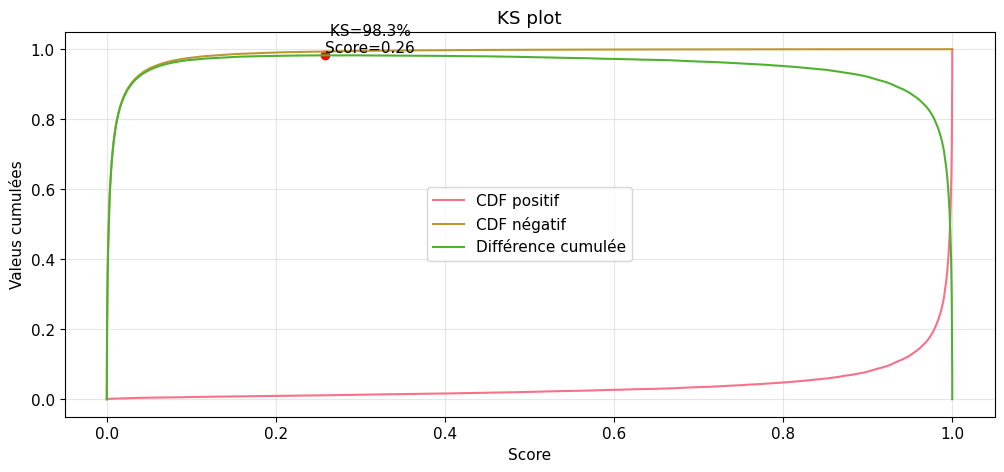

Discrimination forte (KS > 70%)


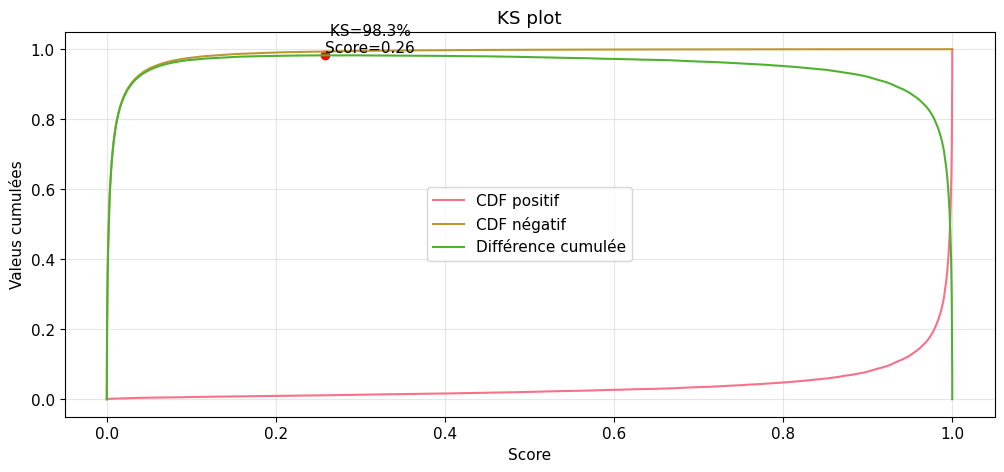

Discrimination forte (KS > 70%)


In [46]:
test_analyser.plot_ks()
oot_analyser.plot_ks()

## quelques plots

### Distribution des scores par classe

Les graphiques empilés montrent la répartition des **bons** (pas de CG < 10 min) et **mauvais** (CG < 10 min) selon les intervalles de score. Un bon score présente une séparation nette des deux populations : les mauvais se concentrent sur les scores élevés.

In [47]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



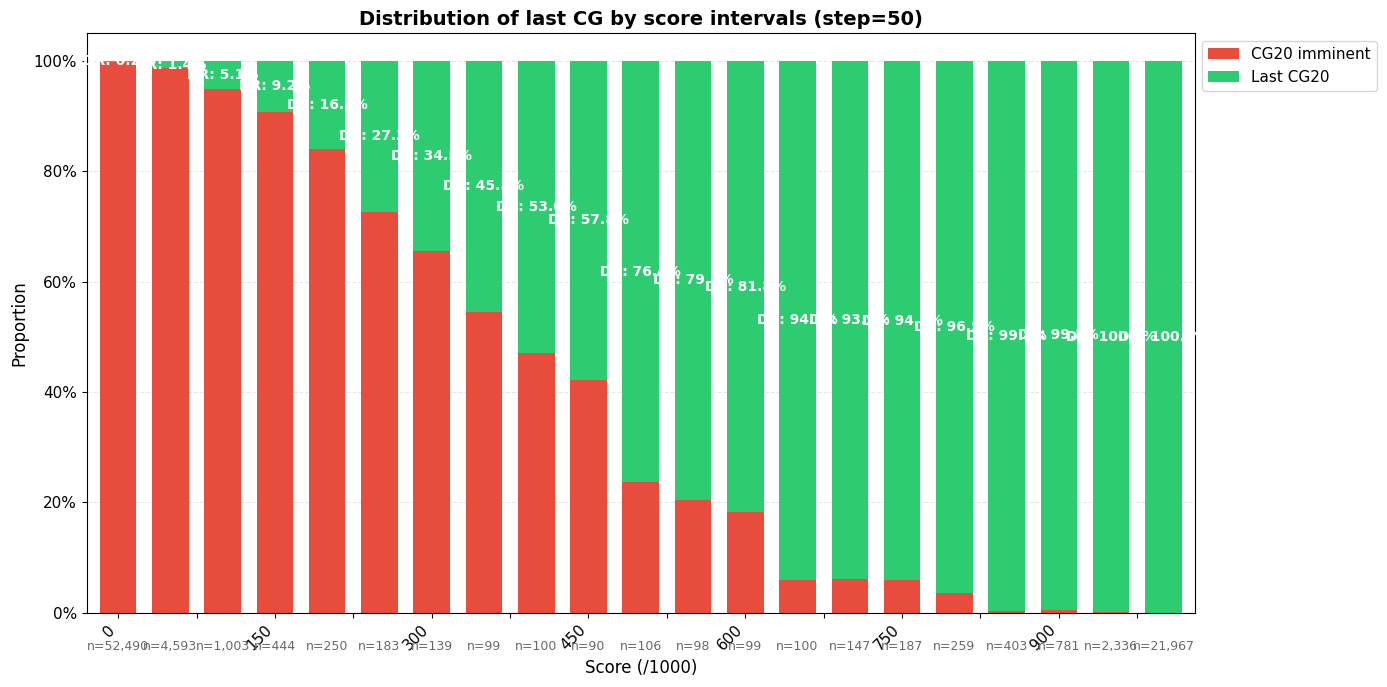


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  52490        52411       79        0.15%
    50   4593         4530       63        1.37%
   100   1003          952       51        5.08%
   150    444          403       41        9.23%
   200    250          210       40       16.00%
   250    183          133       50       27.32%
   300    139           91       48       34.53%
   350     99           54       45       45.45%
   400    100           47       53       53.00%
   450     90           38       52       57.78%
   500    106           25       81       76.42%
   550     98           20       78       79.59%
   600     99           18       81       81.82%
   650    100            6       94       94.00%
   700    147            9      138       93.88%
   750    187           11      176       94.12%
   800    259            9      250       96.53%
   850    403            1      402       99.75%
   900    781            4      777       

In [48]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


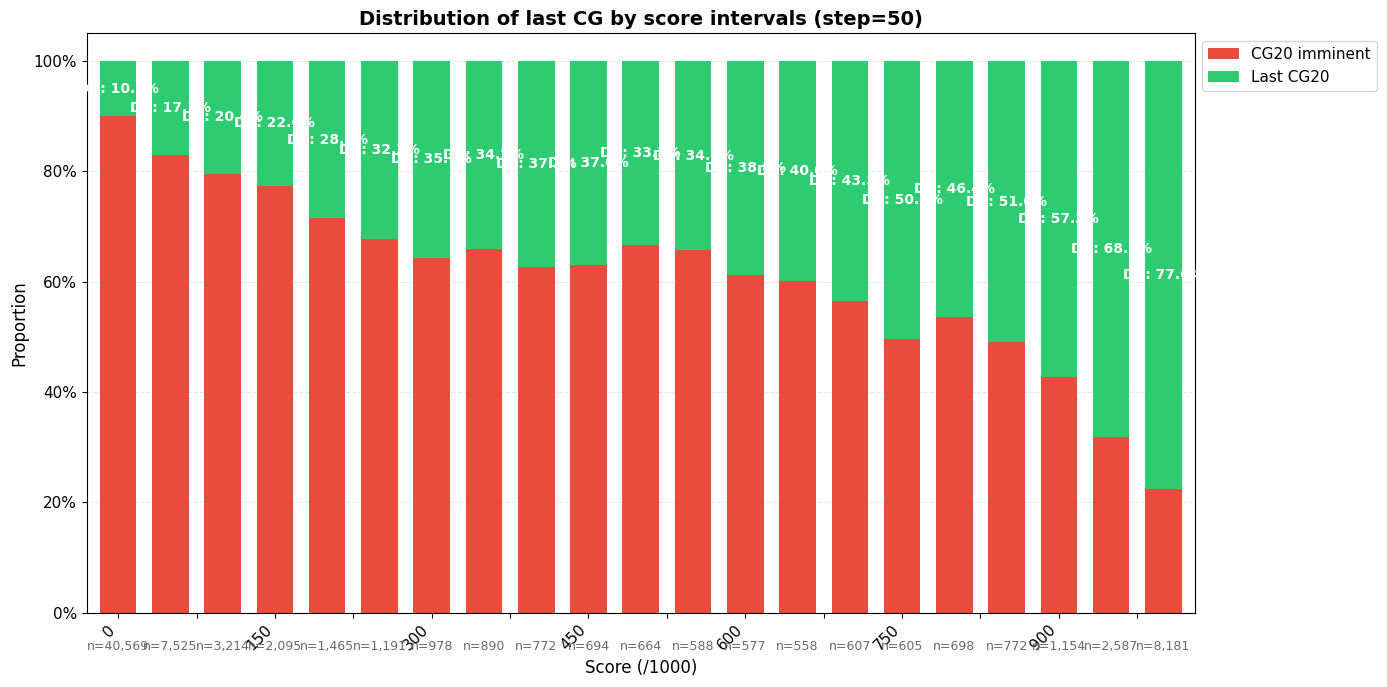


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  40569        36488     4081       10.06%
    50   7525         6236     1289       17.13%
   100   3214         2557      657       20.44%
   150   2095         1621      474       22.63%
   200   1465         1047      418       28.53%
   250   1191          806      385       32.33%
   300    978          629      349       35.69%
   350    890          586      304       34.16%
   400    772          484      288       37.31%
   450    694          437      257       37.03%
   500    664          443      221       33.28%
   550    588          386      202       34.35%
   600    577          353      224       38.82%
   650    558          335      223       39.96%
   700    607          343      264       43.49%
   750    605          300      305       50.41%
   800    698          374      324       46.42%
   850    772          378      394       51.04%
   900   1154          493      661       

In [49]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


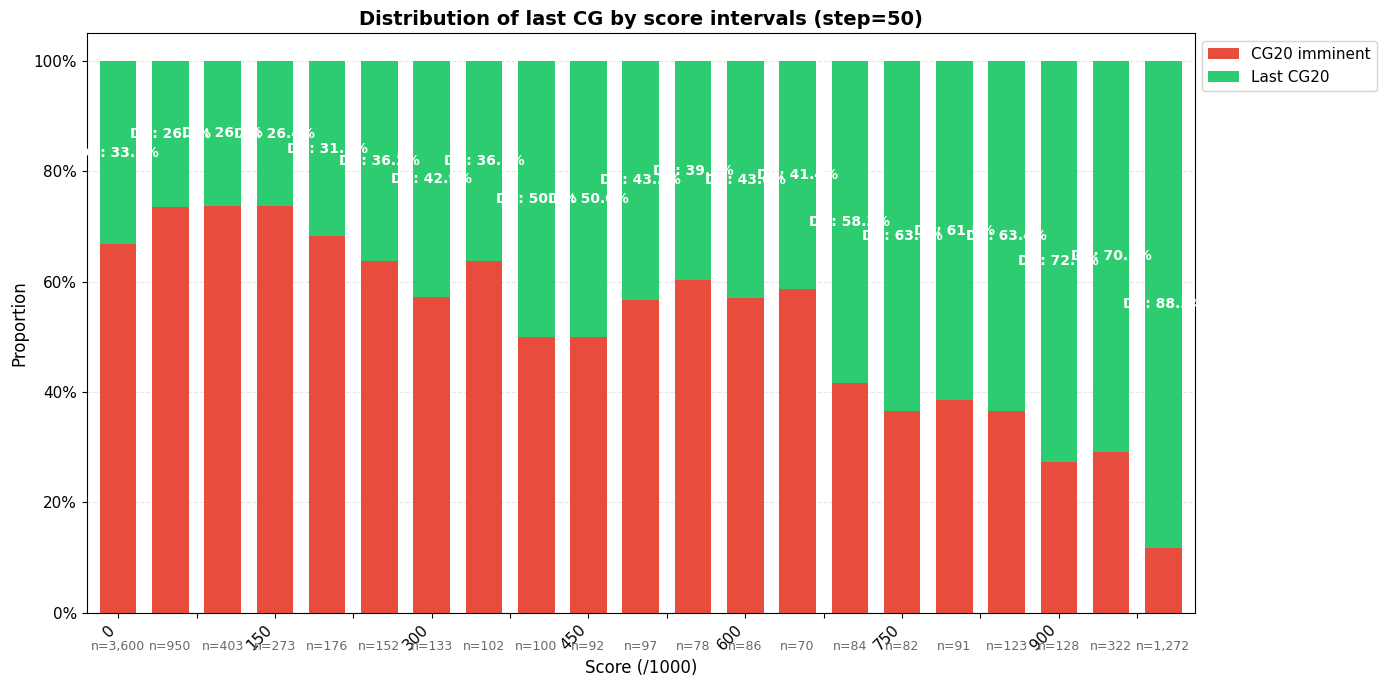


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0   3600         2404     1196       33.22%
    50    950          698      252       26.53%
   100    403          297      106       26.30%
   150    273          201       72       26.37%
   200    176          120       56       31.82%
   250    152           97       55       36.18%
   300    133           76       57       42.86%
   350    102           65       37       36.27%
   400    100           50       50       50.00%
   450     92           46       46       50.00%
   500     97           55       42       43.30%
   550     78           47       31       39.74%
   600     86           49       37       43.02%
   650     70           41       29       41.43%
   700     84           35       49       58.33%
   750     82           30       52       63.41%
   800     91           35       56       61.54%
   850    123           45       78       63.41%
   900    128           35       93       

In [50]:
score_graph_empile(oot_data.loc[oot_data['cg_20km']], score_col='points', label_col=target_col, pas=50)


# Sauvegarde

In [51]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

artefacts = {
    'model'       : model_xgb,
    'vars_to_use' : xgb_vars,
    'best_params' : params,
    'imputer'     : imputer,
    'performance' : {
        'train': {'auc': auc_train, 'gini': gini_train},
        'test' : {'auc': auc_test,  'auc_pr': auc_pr_test, 'rp': rp},
        'oot'  : {'auc': auc_oot,   'auc_pr': auc_pr_oot,  'rp': rp_o},
    },
}

save_path = '../models/xgb_cg30_3km_artefacts.pkl'
joblib.dump(artefacts, save_path)
print(f'Artefacts sauvegardes dans {save_path}')
print(f'  Variables      : {len(xgb_vars)}')
print(f'  Hyperparametres: {list(params.keys())}')
print(f'  ROC AUC train  : {auc_train:.4f}  |  test : {auc_test:.4f}  |  OOT : {auc_oot:.4f}')


Artefacts sauvegardes dans ../models/xgb_cg30_3km_artefacts.pkl
  Variables      : 37
  Hyperparametres: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  ROC AUC train  : 1.0000  |  test : 0.9987  |  OOT : 0.8089
